In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
from matplotlib import pyplot as plt
from utils import *
import pingouin as pg
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.othermod.betareg import BetaModel
from statsmodels.formula.api import gls
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme("paper")
sns.set_palette("mako_r")

PALETTE = sns.color_palette("mako_r", as_cmap=True)

# LOAD DATA

Load datasets containing specificity scores.

- Human ratings
  - Ravelli et al. (2024): ~1K words (ANEW word set)
  - Muraki & Pexman (2026): ~8.5K words

- GPT-4 synthetic ratings
  - Ravelli & Bolognesi (2024): ~1K words (ANEW word set)
  - Ravelli & Bolognesi (this work): ~26K words (Brysbaert word set)


In [ ]:
data_path = "../data"

spec_human_muraki_path = Path(
    data_path, "other", "Specificity_Ratings_Eng.04.17.2025.csv"
)
spec_human_ravelli_path = Path(data_path, "other", "specificity_EN.tsv")

spec_llm_brys_path = Path(
    data_path,
    "brys_specificity_GPT-4.tsv",
)

spec_llm_anew_path = Path(
    data_path,
    "other",
    "specificity_llm_anew.tsv",
)

spec_human_muraki_df = pd.read_csv(
    spec_human_muraki_path, sep=",", na_values=[""], keep_default_na=False
)
# rename columns and skip unused ones
spec_human_muraki_df = spec_human_muraki_df[["Word", "Value"]].rename(
    columns={"Word": "word", "Value": "specificity"}
)

spec_human_ravelli_df = pd.read_csv(
    spec_human_ravelli_path, sep="\t", na_values=[""], keep_default_na=False
)

spec_llm_brys_df = pd.read_csv(
    spec_llm_brys_path, sep="\t", na_values=[""], keep_default_na=False
)
spec_llm_anew_df = pd.read_csv(
    spec_llm_anew_path, sep="\t", na_values=[""], keep_default_na=False
)

# scale all datasets to [0, 1]
spec_human_muraki_df = scale_columns(spec_human_muraki_df, ["specificity"])
spec_human_ravelli_df = scale_columns(spec_human_ravelli_df, ["specificity"])
spec_llm_brys_df = scale_columns(spec_llm_brys_df, ["specificity"])
spec_llm_anew_df = scale_columns(spec_llm_anew_df, ["specificity"])

In [4]:
print(f"Muraki Human Data\nTotal: {len(spec_human_muraki_df)}\n")
print(f"Ravelli Human Data\nTotal: {len(spec_human_ravelli_df)}\n")
print(f"Brys LLM Data\nTotal: {len(spec_llm_brys_df)}\n")
print(f"ANEW LLM Data\nTotal: {len(spec_llm_anew_df)}\n")

Muraki Human Data
Total: 8513

Ravelli Human Data
Total: 1034

Brys LLM Data
Total: 26071

ANEW LLM Data
Total: 1034



# COMPARING MULTIPLE SPECIFICITY RATINGS

## Human vs. Human

Comparison between the datasets from Ravelli et al. (2024) and Muraki & Pexman (2026).


Human Data
Shared words: 642



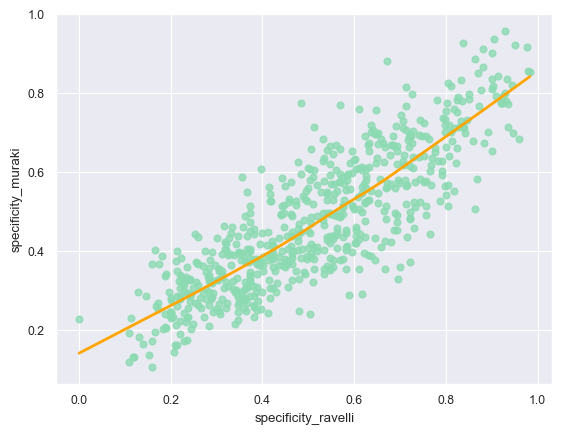

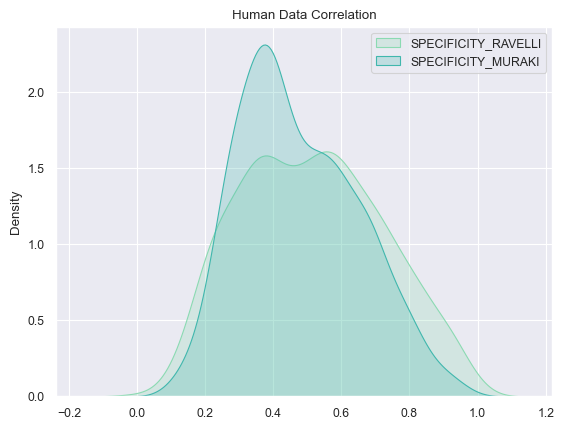

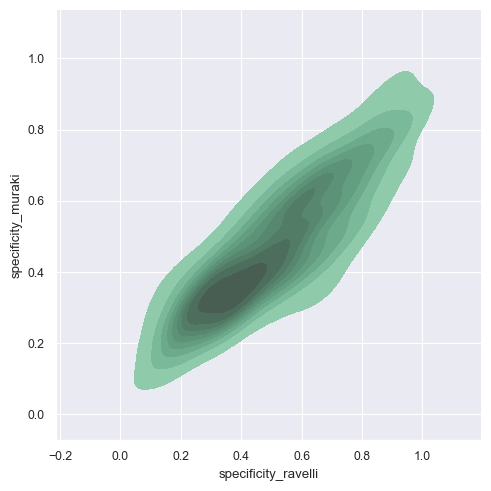

Performing statistical analysis between SPECIFICITY_MURAKI and SPECIFICITY_RAVELLI...

Performing Shapiro-Wilk test for normality...
Based on the Shapiro-Wilk test, at least one variable is not normally distributed.
Executing SPEARMAN correlation
            n         r         CI95%          p-val  power
spearman  642  0.842583  [0.82, 0.86]  3.679659e-174    1.0

############################

Performing regression analysis with formula: SPECIFICITY_RAVELLI ~ SPECIFICITY_MURAKI
                             GLS Regression Results                            
Dep. Variable:     specificity_ravelli   R-squared:                       0.720
Model:                             GLS   Adj. R-squared:                  0.719
Method:                  Least Squares   F-statistic:                     1644.
Date:                 Tue, 20 May 2025   Prob (F-statistic):          5.66e-179
Time:                         12:21:01   Log-Likelihood:                 509.27
No. Observations:                  6

In [5]:
human_corr_df = pd.merge(
    left=spec_human_ravelli_df,
    right=spec_human_muraki_df,
    on="word",
    suffixes=("_ravelli", "_muraki"),
)
print(f"Human Data\nShared words: {len(human_corr_df)}\n")
look_at(
    human_corr_df,
    "specificity_ravelli",
    "specificity_muraki",
    title="Human Data Correlation",
)
do_stats(human_corr_df, x="specificity_muraki", y="specificity_ravelli")

### Results

We observe a strong positive correlation between the human specificity ratings reported by Ravelli et al. (2024) and those from Muraki & Pexman (forthcoming) (Spearman’s ρ = 0.843, p < 0.001).

The regression analysis further confirms this strong relationship (R² = 0.720), indicating that 72% of the variance in specificity scores for the smaller ANEW dataset is explained by the corresponding scores in the larger Muraki dataset. The regression coefficients show an almost one-to-one relationship: the slope for the independent variable (Muraki’s specificity scores) is 1.009, and the intercept is 0.034.

Overall, these results indicate a high level of consistency between two independently collected datasets, supporting the reliability of the Best–Worst Scaling (BWS) method across different participant samples and word sets.


## LLM vs. LLM

Comparison between the GPT-4–generated specificity scores from Ravelli & Bolognesi (2024) and Ravelli & Bolognesi (this work).


LLM Data
Shared words: 1003



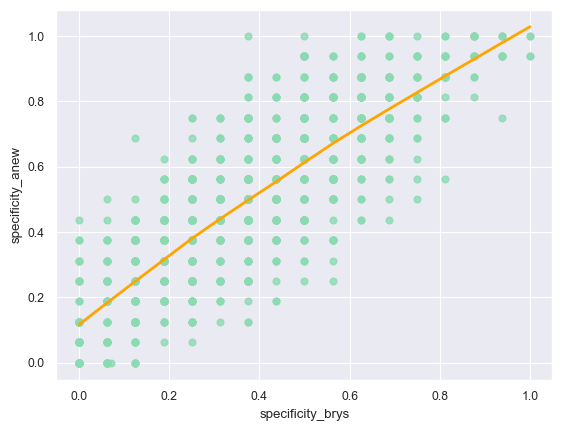

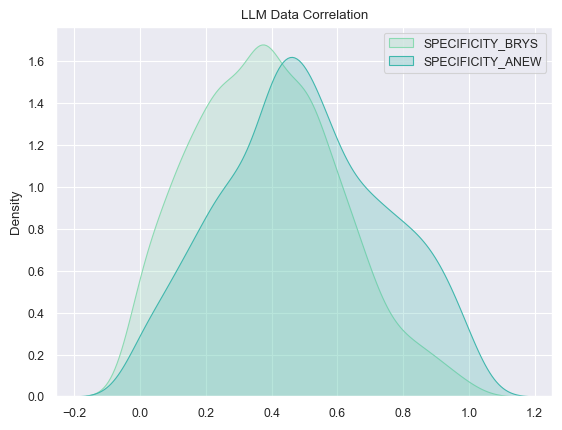

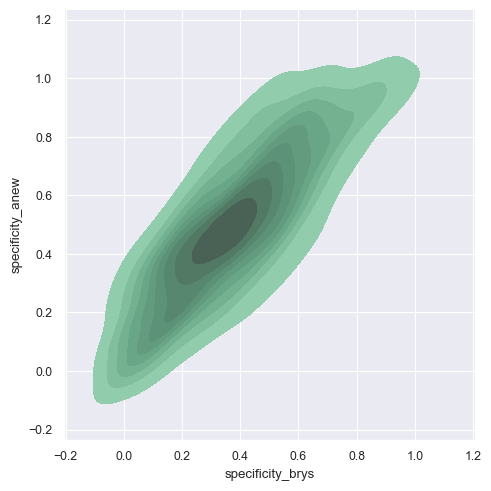

Performing statistical analysis between SPECIFICITY_BRYS and SPECIFICITY_ANEW...

Performing Shapiro-Wilk test for normality...
Based on the Shapiro-Wilk test, at least one variable is not normally distributed.
Executing SPEARMAN correlation
             n         r         CI95%          p-val  power
spearman  1003  0.808968  [0.79, 0.83]  3.395126e-233    1.0

############################

Performing regression analysis with formula: SPECIFICITY_ANEW ~ SPECIFICITY_BRYS
                            GLS Regression Results                            
Dep. Variable:       specificity_anew   R-squared:                       0.664
Model:                            GLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     1974.
Date:                Tue, 20 May 2025   Prob (F-statistic):          5.40e-239
Time:                        12:21:01   Log-Likelihood:                 527.60
No. Observations:                1003   AIC:      

In [6]:
llm_corr_df = pd.merge(
    left=spec_llm_brys_df,
    right=spec_llm_anew_df,
    on="word",
    suffixes=("_brys", "_anew"),
)
print(f"LLM Data\nShared words: {len(llm_corr_df)}\n")
look_at(
    llm_corr_df,
    "specificity_brys",
    "specificity_anew",
    title="LLM Data Correlation",
)
do_stats(llm_corr_df, "specificity_brys", "specificity_anew")

### Results

The analysis reveals a strong positive correlation between GPT-4 specificity ratings for the ANEW and Brysbaert word sets (Spearman’s ρ = 0.81, p < 0.001).

Regression analysis supports this relationship, showing that the Brysbaert-based ratings explain approximately 66% of the variance in the ANEW ratings (R² = 0.664). The regression coefficient (0.92) indicates a nearly one-to-one relationship between the two sets, with a small positive intercept of 0.15.

These findings demonstrate that GPT-4 produces consistent specificity ratings across different word sets, suggesting that the model has developed a stable internal representation of specificity that generalizes well across various lexical datasets.


## LLM vs. Human (ANEW)

Comparison between GPT-4–generated specificity scores from Ravelli & Bolognesi (2024) and human ratings reported by Ravelli et al. (2024), both based on the ANEW word set.


ANEW Data
Shared words: 1034



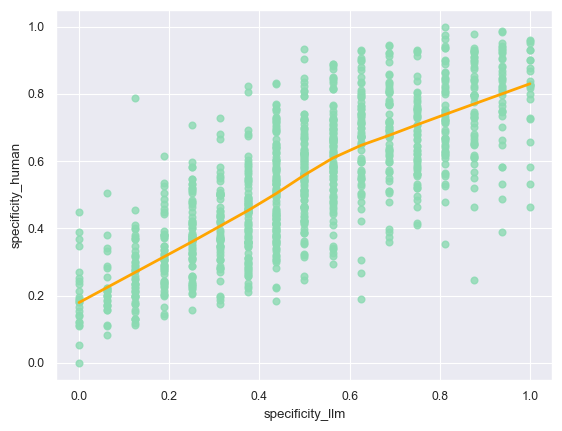

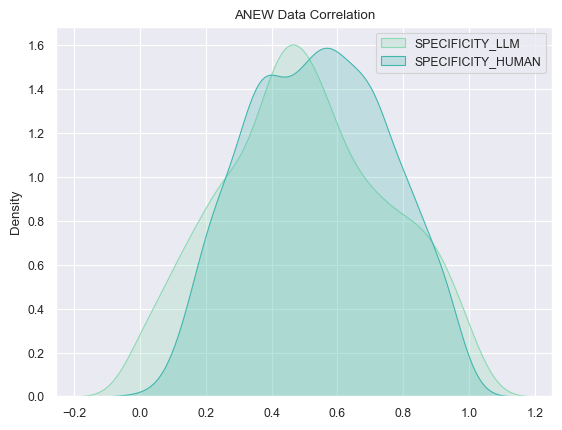

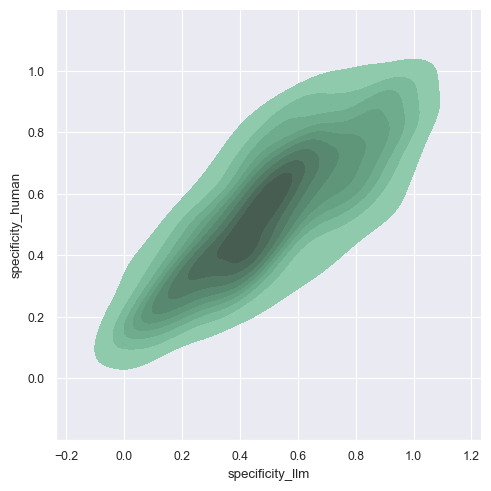

Performing statistical analysis between SPECIFICITY_LLM and SPECIFICITY_HUMAN...

Performing Shapiro-Wilk test for normality...
Based on the Shapiro-Wilk test, at least one variable is not normally distributed.
Executing SPEARMAN correlation
             n         r        CI95%          p-val  power
spearman  1034  0.773427  [0.75, 0.8]  1.519232e-206    1.0

############################

Performing regression analysis with formula: SPECIFICITY_HUMAN ~ SPECIFICITY_LLM
                            GLS Regression Results                            
Dep. Variable:      specificity_human   R-squared:                       0.591
Model:                            GLS   Adj. R-squared:                  0.591
Method:                 Least Squares   F-statistic:                     1493.
Date:                Tue, 20 May 2025   Prob (F-statistic):          1.01e-202
Time:                        12:21:01   Log-Likelihood:                 606.96
No. Observations:                1034   AIC:        

In [7]:
anew_corr_df_llm = pd.merge(
    left=spec_llm_anew_df,
    right=spec_human_ravelli_df,
    on="word",
    suffixes=("_llm", "_human"),
)
print(f"ANEW Data\nShared words: {len(anew_corr_df_llm)}\n")
look_at(
    anew_corr_df_llm,
    "specificity_llm",
    "specificity_human",
    title="ANEW Data Correlation",
)
do_stats(anew_corr_df_llm, x="specificity_llm", y="specificity_human")

### Results

The results (replicated from the original study) show a strong positive correlation between GPT-4 specificity ratings and human ratings from Ravelli et al. (2024) on the ANEW word set (Spearman’s ρ = 0.773, p < 0.001).

Regression analysis further supports this relationship: GPT-4 ratings account for approximately 59% of the variance in human ratings (R² = 0.591). The regression equation (specificity_human = 0.214 + 0.653 × specificity_llm) indicates that while the LLM captures relative differences in specificity well, it systematically rates words slightly differently from humans.

The high statistical significance of both correlation and regression analyses (p < 0.001) provides strong evidence that GPT-4’s understanding of lexical specificity substantially aligns with human judgments. These findings demonstrate that LLMs can generate specificity ratings that meaningfully approximate human intuitions, potentially enabling cost-effective expansion of lexical resources, as highlighted in Ravelli & Bolognesi (2024).


ANEW Data
Shared words: 1003



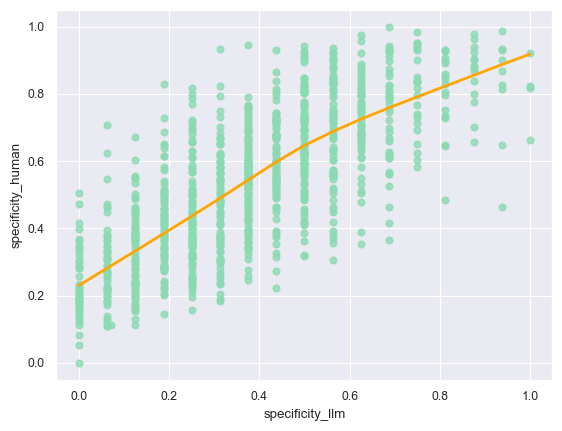

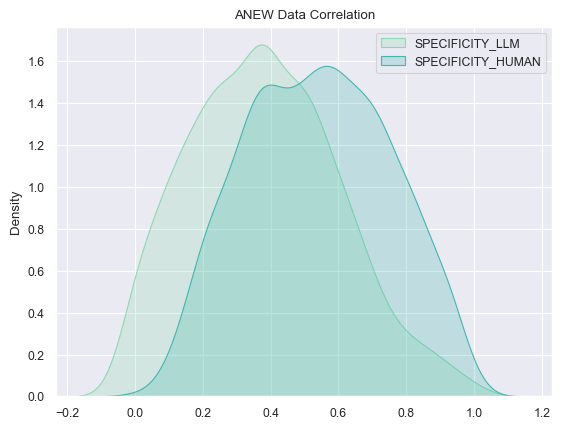

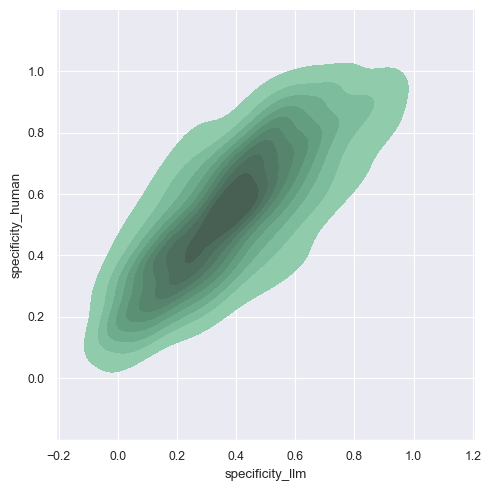

Performing statistical analysis between SPECIFICITY_LLM and SPECIFICITY_HUMAN...

Performing Shapiro-Wilk test for normality...
Based on the Shapiro-Wilk test, at least one variable is not normally distributed.
Executing SPEARMAN correlation
             n         r         CI95%          p-val  power
spearman  1003  0.753472  [0.73, 0.78]  1.677387e-184    1.0

############################

Performing regression analysis with formula: SPECIFICITY_HUMAN ~ SPECIFICITY_LLM
                            GLS Regression Results                            
Dep. Variable:      specificity_human   R-squared:                       0.562
Model:                            GLS   Adj. R-squared:                  0.561
Method:                 Least Squares   F-statistic:                     1283.
Date:                Tue, 20 May 2025   Prob (F-statistic):          1.49e-181
Time:                        12:21:02   Log-Likelihood:                 552.77
No. Observations:                1003   AIC:      

In [8]:
anew_corr_df_llm_2 = pd.merge(
    left=spec_llm_brys_df,
    right=spec_human_ravelli_df,
    on="word",
    suffixes=("_llm", "_human"),
)
print(f"ANEW Data\nShared words: {len(anew_corr_df_llm_2)}\n")
look_at(
    anew_corr_df_llm_2,
    "specificity_llm",
    "specificity_human",
    title="ANEW Data Correlation",
)
do_stats(anew_corr_df_llm_2, x="specificity_llm", y="specificity_human")

When switching the LLM word set from ANEW to Brysbaert, both the correlation and the regression’s explanatory power decrease by only about 2%, a negligible drop that indicates the relationship between LLM and human specificity remains very stable across different and larger word sets.

Meanwhile, the regression coefficient increases from 0.653 to 0.722 (+7%), showing that LLM-derived specificity has a slightly stronger influence on predicted human ratings. In other words, the scale of LLM estimates becomes more closely aligned with the human scale.

Overall, these observations demonstrate that the LLM effectively approximates human specificity ratings even when applied to a broader and more diverse lexicon. The model is not overfitted to a particular word set. We conclude that LLM-generated specificity estimates are reliable and transferable across different datasets, making them valuable for expanding linguistic resources.


## LLM vs. Human (Muraki & Pexman)

Comparison between GPT-4–generated specificity scores from Ravelli & Bolognesi (this work) and human ratings reported by Muraki & Pexman (2026).


Muraki Data
Shared words: 8482



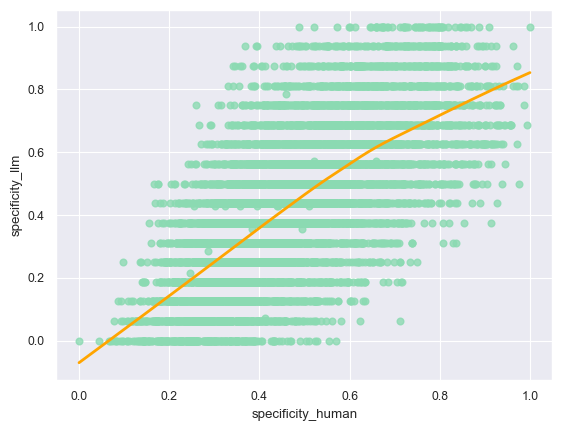

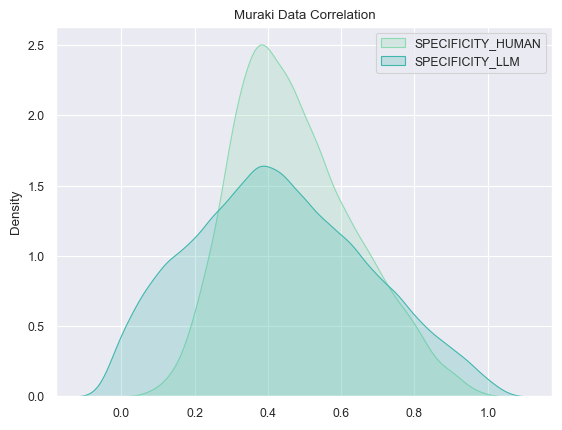

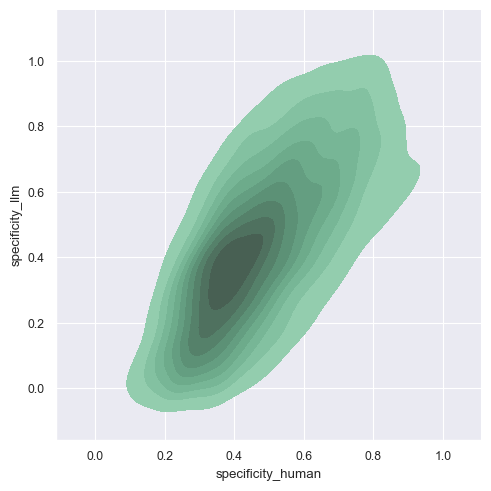

Performing statistical analysis between SPECIFICITY_LLM and SPECIFICITY_HUMAN...

Performing Jarque-Bera test for normality...
Based on the Jarque-Bera test, at least one variable is not normally distributed.
Executing SPEARMAN correlation
             n         r         CI95%  p-val  power
spearman  8482  0.677733  [0.67, 0.69]    0.0    1.0

############################

Performing regression analysis with formula: SPECIFICITY_HUMAN ~ SPECIFICITY_LLM
                            GLS Regression Results                            
Dep. Variable:      specificity_human   R-squared:                       0.456
Model:                            GLS   Adj. R-squared:                  0.456
Method:                 Least Squares   F-statistic:                     7106.
Date:                Tue, 20 May 2025   Prob (F-statistic):               0.00
Time:                        12:21:05   Log-Likelihood:                 5743.9
No. Observations:                8482   AIC:                        

In [9]:
muraki_corr_df_llm = pd.merge(
    left=spec_human_muraki_df,
    right=spec_llm_brys_df,
    on="word",
    suffixes=("_human", "_llm"),
)

print(f"Muraki Data\nShared words: {len(muraki_corr_df_llm)}\n")

look_at(
    muraki_corr_df_llm,
    "specificity_human",
    "specificity_llm",
    title="Muraki Data Correlation",
)

do_stats(muraki_corr_df_llm, x="specificity_llm", y="specificity_human")

### Results

The analysis reveals a substantial positive correlation between GPT-4–generated and human specificity ratings across a large dataset of 8,482 words (Spearman’s ρ = 0.678, p < 0.001). This relationship is moderately strong, though slightly weaker than what was observed in the smaller ANEW dataset.

Regression analysis supports this finding: LLM ratings account for approximately 45.6% of the variance in human ratings (R² = 0.456). The regression equation (specificity_human = 0.266 + 0.480 × specificity_llm) indicates that while LLM ratings capture significant aspects of human specificity, some adjustment is needed for a closer match to human judgments.

The high statistical significance of these results across such a large dataset provides strong evidence that GPT-4’s understanding of lexical specificity aligns meaningfully with human judgments at scale. Although the alignment is not perfect, LLM-generated specificity ratings can serve as a reliable approximation for large-scale lexical resources, while acknowledging some differences between machine and human evaluations.


Muraki Data
Shared words: 642



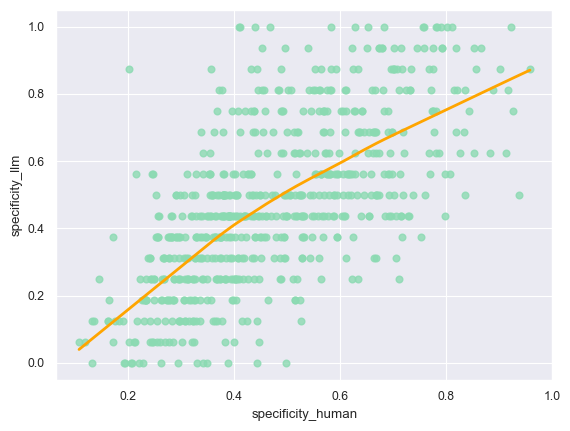

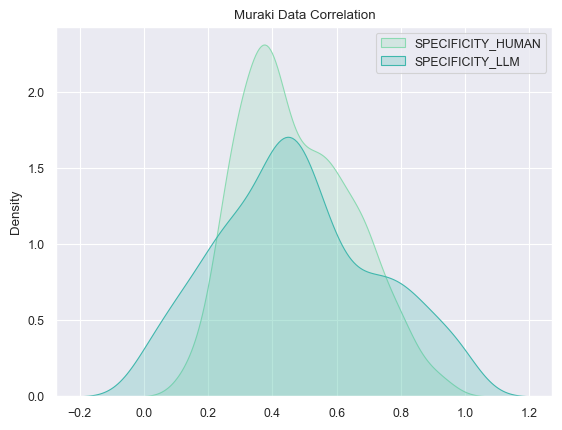

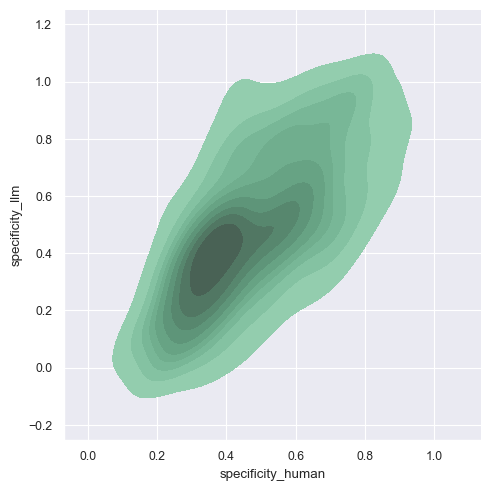

Performing statistical analysis between SPECIFICITY_LLM and SPECIFICITY_HUMAN...

Performing Shapiro-Wilk test for normality...
Based on the Shapiro-Wilk test, at least one variable is not normally distributed.
Executing SPEARMAN correlation
            n         r         CI95%         p-val  power
spearman  642  0.679571  [0.64, 0.72]  3.657483e-88    1.0

############################

Performing regression analysis with formula: SPECIFICITY_HUMAN ~ SPECIFICITY_LLM
                            GLS Regression Results                            
Dep. Variable:      specificity_human   R-squared:                       0.441
Model:                            GLS   Adj. R-squared:                  0.440
Method:                 Least Squares   F-statistic:                     504.4
Date:                Tue, 20 May 2025   Prob (F-statistic):           8.09e-83
Time:                        12:21:05   Log-Likelihood:                 398.71
No. Observations:                 642   AIC:          

In [10]:
muraki_corr_df_llm_2 = pd.merge(
    left=spec_human_muraki_df,
    right=spec_llm_anew_df,
    on="word",
    suffixes=("_human", "_llm"),
)

print(f"Muraki Data\nShared words: {len(muraki_corr_df_llm_2)}\n")

look_at(
    muraki_corr_df_llm_2,
    "specificity_human",
    "specificity_llm",
    title="Muraki Data Correlation",
)

do_stats(muraki_corr_df_llm_2, x="specificity_llm", y="specificity_human")

The results indicate that the Best–Worst Scaling (BWS) method is robust and consistent, regardless of the word set used to construct the tuples. The comparison between LLM and human specificity is very similar across both experiments, with correlations of 0.678 and 0.680, respectively. This demonstrates a stable and consistent relationship even when the word sets change.

The proportion of human specificity variance explained by the LLM is also comparable in both cases (R² = 0.456 vs. 0.441). Likewise, the regression coefficients (0.480 and 0.470) and intercepts (0.266 and 0.251) are nearly identical.

Overall, the relationship between LLM and human specificity is stable and reliable across experiments. These results show that the BWS method produces consistent and comparable outcomes across different samples, supporting its generalizability and reliability for collecting human-like judgments of lexical specificity.


# POS-Specific Correlations

Re-load the Muraki & Pexman dataset along with part-of-speech (POS) information to perform targeted analyses on subsets of nouns, verbs, and adjectives.


In [11]:
pos_df = pd.read_csv(
    spec_human_muraki_path, sep=",", na_values=[""], keep_default_na=False
)

pos_df = pos_df[["Word", "PoS"]]
pos_df = pos_df.rename(columns={"Word": "word", "PoS": "pos"})
pos_df["pos"] = pos_df["pos"].apply(lambda x: x.lower())

nouns = pos_df[pos_df["pos"] == "noun"]["word"].tolist()
verbs = pos_df[pos_df["pos"] == "verb"]["word"].tolist()
adj = pos_df[pos_df["pos"] == "adj"]["word"].tolist()

In [12]:
print(f"Nouns in Muraki & Pexman: {len(nouns)}")
print(f"Verbs in Muraki & Pexman: {len(verbs)}")
print(f"Adjectives in Muraki & Pexman: {len(adj)}")

Nouns in Muraki & Pexman: 5276
Verbs in Muraki & Pexman: 1331
Adjectives in Muraki & Pexman: 1906


## HUMAN vs. HUMAN


### NOUNS


In [13]:
human_corr_NOUNS_df = human_corr_df[human_corr_df["word"].isin(nouns)]

# look_at(
#     human_corr_NOUNS_df,
#     "specificity_ravelli",
#     "specificity_muraki",
#     title="Human Data Correlation (Nouns)",
# )

do_stats(human_corr_NOUNS_df, x="specificity_muraki", y="specificity_ravelli")

Performing statistical analysis between SPECIFICITY_MURAKI and SPECIFICITY_RAVELLI...

Performing Shapiro-Wilk test for normality...
Based on the Shapiro-Wilk test, at least one variable is not normally distributed.
Executing SPEARMAN correlation
            n         r         CI95%          p-val  power
spearman  423  0.900003  [0.88, 0.92]  6.456514e-154    1.0

############################

Performing regression analysis with formula: SPECIFICITY_RAVELLI ~ SPECIFICITY_MURAKI
                             GLS Regression Results                            
Dep. Variable:     specificity_ravelli   R-squared:                       0.819
Model:                             GLS   Adj. R-squared:                  0.818
Method:                  Least Squares   F-statistic:                     1904.
Date:                 Tue, 20 May 2025   Prob (F-statistic):          2.62e-158
Time:                         12:21:05   Log-Likelihood:                 394.78
No. Observations:                  4

Compared to the analysis on the full set of words (nouns, verbs, and adjectives), the noun subset shows stronger results in both correlation and regression. The Spearman correlation is approximately 6% higher (ρ = 0.90) than for the full set. Linear regression also explains a larger proportion of variance (R² = 0.819), with an almost one-to-one relationship between the two estimates (slope ≈ 1.05, intercept ≈ 0).

These findings indicate that consistency in human specificity ratings is particularly high for nouns, likely because their semantics are more stable and widely shared compared to verbs and adjectives.


### VERBS


In [14]:
human_corr_VERBS_df = human_corr_df[human_corr_df["word"].isin(verbs)]
# look_at(
#     human_corr_VERBS_df,
#     "specificity_ravelli",
#     "specificity_muraki",
#     title="Human Data Correlation (Verbs)",
# )
do_stats(human_corr_VERBS_df, x="specificity_muraki", y="specificity_ravelli")

Performing statistical analysis between SPECIFICITY_MURAKI and SPECIFICITY_RAVELLI...

Performing Shapiro-Wilk test for normality...
Based on the Shapiro-Wilk test, at least one variable is not normally distributed.
Executing SPEARMAN correlation
           n         r         CI95%         p-val  power
spearman  76  0.784286  [0.68, 0.86]  5.315590e-17    1.0

############################

Performing regression analysis with formula: SPECIFICITY_RAVELLI ~ SPECIFICITY_MURAKI
                             GLS Regression Results                            
Dep. Variable:     specificity_ravelli   R-squared:                       0.620
Model:                             GLS   Adj. R-squared:                  0.614
Method:                  Least Squares   F-statistic:                     120.5
Date:                 Tue, 20 May 2025   Prob (F-statistic):           3.44e-17
Time:                         12:21:05   Log-Likelihood:                 58.786
No. Observations:                   76  

For verbs, the correlation between human specificity ratings is about 6% lower than for nouns. The Spearman coefficient is ρ = 0.78, indicating good convergence between the two datasets, though less pronounced than for nouns. Linear regression explains a 10% lower proportion of variance (R² = 0.62), while still showing an almost one-to-one relationship between the two estimates (slope ≈ 1.01, intercept ≈ 0).

These results suggest that consistency in human specificity ratings for verbs remains high but is less stable than for nouns, likely due to the greater semantic variability of verbs, which is linked to the compositional nature of verbal meaning.


### ADJECTIVES


In [ ]:
human_corr_ADJ_df = human_corr_df[human_corr_df["word"].isin(adj)]
# look_at(
#     human_corr_ADJ_df,
#     "specificity_ravelli",
#     "specificity_muraki",
#     title="Human Data Correlation (Adjectives)",
# )
do_stats(human_corr_ADJ_df, x="specificity_muraki", y="specificity_ravelli")

Performing statistical analysis between SPECIFICITY_MURAKI and SPECIFICITY_RAVELLI...

Performing Shapiro-Wilk test for normality...
Based on the Shapiro-Wilk test, at least one variable is not normally distributed.
Executing SPEARMAN correlation
            n         r         CI95%         p-val  power
spearman  143  0.758847  [0.68, 0.82]  4.835232e-28    1.0

############################

Performing regression analysis with formula: SPECIFICITY_RAVELLI ~ SPECIFICITY_MURAKI
                             GLS Regression Results                            
Dep. Variable:     specificity_ravelli   R-squared:                       0.554
Model:                             GLS   Adj. R-squared:                  0.551
Method:                  Least Squares   F-statistic:                     175.4
Date:                 Tue, 20 May 2025   Prob (F-statistic):           1.61e-26
Time:                         12:21:05   Log-Likelihood:                 119.01
No. Observations:                  143

For adjectives, the correlation is the lowest among the three categories analyzed. The Spearman coefficient is ρ = 0.76 (p < 1e-27), which is lower than that observed for nouns and verbs, and 8% lower than for the full set. Regression explains a smaller proportion of variance (R² = 0.55), while still showing an almost one-to-one relationship between the two estimates (slope ≈ 1.05). The intercept is slightly positive (0.10), indicating a small scale difference between the datasets.

These results suggest that for adjectives, human specificity ratings are still consistent but less stable than for nouns and verbs, likely due to greater subjectivity and semantic variability typical of this lexical category. Overall, convergence between the two human datasets is strongest for nouns, indicating that this category provides the most reliable and replicable conditions for evaluating specificity.


## LLM vs. HUMAN (Muraki & Pexman)


### NOUNS


In [16]:
muraki_corr_NOUNS_df = muraki_corr_df_llm[muraki_corr_df_llm["word"].isin(nouns)]

# look_at(
#     muraki_corr_NOUNS_df,
#     "specificity_human",
#     "specificity_llm",
#     title="Muraki Data Correlation (NOUNS)",
# )
do_stats(muraki_corr_NOUNS_df, x="specificity_llm", y="specificity_human")

Performing statistical analysis between SPECIFICITY_LLM and SPECIFICITY_HUMAN...

Performing Jarque-Bera test for normality...
Based on the Jarque-Bera test, at least one variable is not normally distributed.
Executing SPEARMAN correlation
             n         r         CI95%  p-val  power
spearman  5269  0.718756  [0.71, 0.73]    0.0    1.0

############################

Performing regression analysis with formula: SPECIFICITY_HUMAN ~ SPECIFICITY_LLM
                            GLS Regression Results                            
Dep. Variable:      specificity_human   R-squared:                       0.494
Model:                            GLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     5151.
Date:                Tue, 20 May 2025   Prob (F-statistic):               0.00
Time:                        12:21:05   Log-Likelihood:                 3163.9
No. Observations:                5269   AIC:                        

Analysis of nouns only, comparing human and LLM specificity ratings, reveals a Spearman correlation of ρ = 0.72—approximately 4% higher than the correlation observed across all words—further highlighting the stability of nominal semantics. Linear regression explains about 3% more of the variance in human specificity based on LLM estimates (R² = 0.494).


### VERBS


In [17]:
muraki_corr_VERBS_df = muraki_corr_df_llm[muraki_corr_df_llm["word"].isin(verbs)]

# look_at(
#     muraki_corr_VERBS_df,
#     "specificity_human",
#     "specificity_llm",
#     title="Muraki Data Correlation (VERBS)",
# )
do_stats(muraki_corr_VERBS_df, x="specificity_llm", y="specificity_human")

Performing statistical analysis between SPECIFICITY_LLM and SPECIFICITY_HUMAN...

Performing Shapiro-Wilk test for normality...
Based on the Shapiro-Wilk test, at least one variable is not normally distributed.
Executing SPEARMAN correlation
             n         r         CI95%          p-val  power
spearman  1307  0.661997  [0.63, 0.69]  1.271634e-165    1.0

############################

Performing regression analysis with formula: SPECIFICITY_HUMAN ~ SPECIFICITY_LLM
                            GLS Regression Results                            
Dep. Variable:      specificity_human   R-squared:                       0.438
Model:                            GLS   Adj. R-squared:                  0.437
Method:                 Least Squares   F-statistic:                     1016.
Date:                Tue, 20 May 2025   Prob (F-statistic):          2.50e-165
Time:                        12:21:05   Log-Likelihood:                 1228.4
No. Observations:                1307   AIC:      

For verbs, the correlation between LLM and human specificity ratings is lower than for nouns, consistent with trends observed in human-only analyses. The Spearman coefficient is ρ = 0.66, and regression explains about 44% of the variance in human specificity based on LLM estimates (R² = 0.438), approximately 2% less than for the full dataset.

The regression equation (specificity_human = 0.327 + 0.381 × specificity_llm) shows a slope substantially below 1 and a higher intercept than for nouns, indicating that LLM estimates tend to underestimate verb specificity relative to human judgments.


### ADJECTIVES


In [18]:
muraki_corr_ADJ_df = muraki_corr_df_llm[muraki_corr_df_llm["word"].isin(adj)]

# look_at(
#     muraki_corr_ADJ_df,
#     "specificity_human",
#     "specificity_llm",
#     title="Muraki Data Correlation (ADJECTIVES)",
# )
do_stats(muraki_corr_ADJ_df, x="specificity_llm", y="specificity_human")

Performing statistical analysis between SPECIFICITY_LLM and SPECIFICITY_HUMAN...

Performing Shapiro-Wilk test for normality...
Based on the Shapiro-Wilk test, at least one variable is not normally distributed.
Executing SPEARMAN correlation
             n         r        CI95%          p-val  power
spearman  1906  0.572333  [0.54, 0.6]  2.673305e-166    1.0

############################

Performing regression analysis with formula: SPECIFICITY_HUMAN ~ SPECIFICITY_LLM
                            GLS Regression Results                            
Dep. Variable:      specificity_human   R-squared:                       0.375
Model:                            GLS   Adj. R-squared:                  0.375
Method:                 Least Squares   F-statistic:                     1144.
Date:                Tue, 20 May 2025   Prob (F-statistic):          8.00e-197
Time:                        12:21:05   Log-Likelihood:                 1663.6
No. Observations:                1906   AIC:        

For adjectives, the correlation between LLM and human specificity ratings is the lowest among the three lexical categories analyzed, consistent with trends observed in human-only data. The Spearman coefficient is ρ = 0.57, 11% lower than for the full dataset, and linear regression explains approximately 38% of the variance in human specificity based on LLM estimates (R² = 0.375), a 10% decrease.

The regression slope is even lower than that observed for verbs, indicating that LLM estimates for adjectives tend to underestimate specificity more strongly compared to human judgments.


# to recap...


In [19]:
spearman_total = round(
    pg.corr(
        muraki_corr_df_llm["specificity_human"],
        muraki_corr_df_llm["specificity_llm"],
        method="spearman",
    )["r"].values[0],
    ndigits=3,
)
spearman_nouns = round(
    pg.corr(
        muraki_corr_NOUNS_df["specificity_human"],
        muraki_corr_NOUNS_df["specificity_llm"],
        method="spearman",
    )["r"].values[0],
    ndigits=3,
)
spearman_verbs = round(
    pg.corr(
        muraki_corr_VERBS_df["specificity_human"],
        muraki_corr_VERBS_df["specificity_llm"],
        method="spearman",
    )["r"].values[0],
    ndigits=3,
)
spearman_adj = round(
    pg.corr(
        muraki_corr_ADJ_df["specificity_human"],
        muraki_corr_ADJ_df["specificity_llm"],
        method="spearman",
    )["r"].values[0],
    ndigits=3,
)


rsquared_total = round(
    gls(formula="specificity_human ~ specificity_llm", data=muraki_corr_df_llm)
    .fit()
    .rsquared,
    ndigits=3,
)
rsquared_nouns = round(
    gls(formula="specificity_human ~ specificity_llm", data=muraki_corr_NOUNS_df)
    .fit()
    .rsquared,
    ndigits=3,
)
rsquared_verbs = round(
    gls(formula="specificity_human ~ specificity_llm", data=muraki_corr_VERBS_df)
    .fit()
    .rsquared,
    ndigits=3,
)
rsquared_adj = round(
    gls(formula="specificity_human ~ specificity_llm", data=muraki_corr_ADJ_df)
    .fit()
    .rsquared,
    ndigits=3,
)

print("LLM vs. humans (Muraki)")
print(f"Total words: {len(muraki_corr_df_llm)}")

print(
    f"Total nouns: {len(muraki_corr_NOUNS_df)} ({len(muraki_corr_NOUNS_df) / len(muraki_corr_df_llm) * 100:.2f}%)"
)

print(
    f"Total verbs: {len(muraki_corr_VERBS_df)} ({len(muraki_corr_VERBS_df) / len(muraki_corr_df_llm) * 100:.2f}%)"
)

print(
    f"Total adjectives: {len(muraki_corr_ADJ_df)} ({len(muraki_corr_ADJ_df) / len(muraki_corr_df_llm) * 100:.2f}%)"
)

print("\n############################\n")

print("Spearman Correlations:\n")
print(f"TOTAL:{spearman_total}\n")
print(
    f"NOUNS:{spearman_nouns} ({round((spearman_nouns - spearman_total) * 100, ndigits=2)}%)"
)
print(
    f"VERBS:{spearman_verbs} ({round((spearman_verbs - spearman_total) * 100, ndigits=2)}%)"
)
print(
    f"ADJECTIVES:{spearman_adj} ({round((spearman_adj - spearman_total) * 100, ndigits=2)}%)"
)
print("\n############################\n")
# print("Beta Regression:")
# print(f"TOTAL:{BetaModel.from_formula('specificity_human ~ specificity_llm', data=muraki_corr_df_llm).fit().summary()}")
# print(f"NOUNS:{BetaModel.from_formula('specificity_human ~ specificity_llm', data=muraki_corr_NOUNS_df).fit().summary()}")
# print(f"VERBS:{BetaModel.from_formula('specificity_human ~ specificity_llm', data=muraki_corr_VERBS_df).fit().summary()}")
# print(f"ADJECTIVES:{BetaModel.from_formula('specificity_human ~ specificity_llm', data=muraki_corr_ADJ_df).fit().summary()}")
# print("\n############################\n")
print("Generalized Least Squares:\n")
print(f"TOTAL:{rsquared_total}\n")
print(
    f"NOUNS:{rsquared_nouns} ({round((rsquared_nouns - rsquared_total) * 100, ndigits=2)}%)"
)
print(
    f"VERBS:{rsquared_verbs} ({round((rsquared_verbs - rsquared_total) * 100, ndigits=2)}%)"
)
print(
    f"ADJECTIVES:{rsquared_adj} ({round((rsquared_adj - rsquared_total) * 100, ndigits=2)}%)"
)
print("\n############################")

LLM vs. humans (Muraki)
Total words: 8482
Total nouns: 5269 (62.12%)
Total verbs: 1307 (15.41%)
Total adjectives: 1906 (22.47%)

############################

Spearman Correlations:

TOTAL:0.678

NOUNS:0.719 (4.1%)
VERBS:0.662 (-1.6%)
ADJECTIVES:0.572 (-10.6%)

############################

Generalized Least Squares:

TOTAL:0.456

NOUNS:0.494 (3.8%)
VERBS:0.438 (-1.8%)
ADJECTIVES:0.375 (-8.1%)

############################


### Summary of Results: LLM vs. Humans (Muraki & Pexman)

Analysis of 8,482 words shows a positive and significant correlation between LLM-generated and human specificity ratings (Spearman’s ρ = 0.678), with a substantial portion of variance explained (R² = 0.456). The strength of this relationship, however, varies by grammatical category:

- **Nouns**: Highest correlation (ρ = 0.719, +4.1% compared to the overall) and greatest variance explained by regression (R² = 0.494, +3.8%), confirming that nominal specificity is more stable and better captured by the model.
- **Verbs**: Slightly lower correlation than the overall set (ρ = 0.662, -1.6%) and similar variance explained (R² = 0.438, -1.8%), reflecting the greater semantic variability of verbs.
- **Adjectives**: Lowest correlation (ρ = 0.572, -10.6%) and least variance explained (R² = 0.375, -8.1%), indicating that adjectives are semantically more opaque and harder to model for both humans and LLMs.
